In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import ast
import os
from tqdm import tqdm

import torch

from scipy.stats import pearsonr, spearmanr, zscore

In [2]:
weights = torch.load(f'../train_notebooks/weights/extended_doublemlp/weights.pt', map_location='cpu', weights_only=False)

In [3]:
weights['model_state_dict']

OrderedDict([('global_lamb', tensor(3.4894)),
             ('alpha', tensor(-0.2008)),
             ('beta', tensor(-0.0761)),
             ('gamma', tensor(1.8626)),
             ('cutoff', tensor(0.2805)),
             ('smooth', tensor(1.7840)),
             ('force', tensor(1.4765)),
             ('history_items',
              tensor([[   0,    0,    0,  ...,    0,    0,    0],
                      [   1,    2,    3,  ...,    0,    0,    0],
                      [ 576,  211,  577,  ...,    0,    0,    0],
                      ...,
                      [ 678,  276,  319,  ...,    0,    0,    0],
                      [1471, 2822, 2701,  ...,    0,    0,    0],
                      [ 699,  455,  396,  ...,    0,    0,    0]])),
             ('history_times',
              tensor([[         0,          0,          0,  ...,          0,          0,
                                0],
                      [1654072390, 1654072708, 1654072940,  ...,          0,          0,
         

In [4]:
data_path = '../optimized/predict_notebooks/curves'
weight_path = '../train_notebooks/weights'

models = ['original', 'extendedBase', 'extended_double', 'extended_doublemlp']

In [5]:
df_full = pd.read_parquet('../sorted_data.parquet')

In [6]:
def similarity(data):
    data = data.copy()
    a = np.vstack(data)[0, :]
    b = np.vstack(data)[1, :]
    return pearsonr(a, b).statistic

In [7]:
from src.models.optimized.extendedMLDist import Ex2VecExtendedMLP

In [8]:
def interpolate_array(arr):
    arr_float = arr.astype(float)
    valid = ~np.isnan(arr_float)
    indices = np.arange(len(arr_float))
    arr_float[np.isnan(arr_float)] = np.interp(indices[np.isnan(arr_float)], indices[valid], arr_float[valid])
    return arr_float

In [9]:
df_curves = pd.read_csv('../optimized/predict_notebooks/curves/extended_doublemlp_predictions_for_curves.csv')
df_curves['score'] = df_curves['score'].apply(lambda x: np.array(ast.literal_eval(re.sub(r'np\.float64\(([^)]+)\)', r'\1', x).replace('nan', 'None')))).apply(interpolate_array)
df_curves['prob'] = df_curves['prob'].apply(lambda x: np.array(ast.literal_eval(re.sub(r'np\.float64\(([^)]+)\)', r'\1', x).replace('nan', 'None')))).apply(interpolate_array)

In [10]:
df_curves

,user,item,score,prob
0,1.0,208.0,"[-3.487718105316162, -3.487718105316162, -3.46...","[0.0010720934951677918, 0.0010720934951677918,..."
1,1.0,380.0,"[-6.115856170654297, -6.115856170654297, -4.83...","[7.741886656731367e-05, 7.741886656731367e-05,..."
2,2.0,594.0,"[-8.33913803100586, -8.33913803100586, -8.3391...","[0.0001678132830420509, 0.0001678132830420509,..."
3,2.0,673.0,"[-4.424111366271973, -4.424111366271973, -4.42...","[0.008415904827415943, 0.008415904827415943, 0..."
4,3.0,71.0,"[-4.488868236541748, -4.488868236541748, -4.48...","[0.0010777079733088613, 0.0010777079733088613,..."
...,...,...,...,...
26413,13207.0,1055.0,"[-9.996683120727539, -9.996683120727539, -9.99...","[1.6910671547520906e-05, 1.6910671547520906e-0..."
26414,13208.0,1311.0,"[-6.347343921661377, -6.347343921661377, -5.56...","[0.0008481089025735855, 0.0008481089025735855,..."
26415,13208.0,1640.0,"[-5.819157123565674, -5.819157123565674, -5.58...","[0.0014382692752406001, 0.0014382692752406001,..."
26416,13209.0,453.0,"[-6.58095645904541, -6.58095645904541, -6.5809...","[0.00031384016619995236, 0.0003138401661999523..."


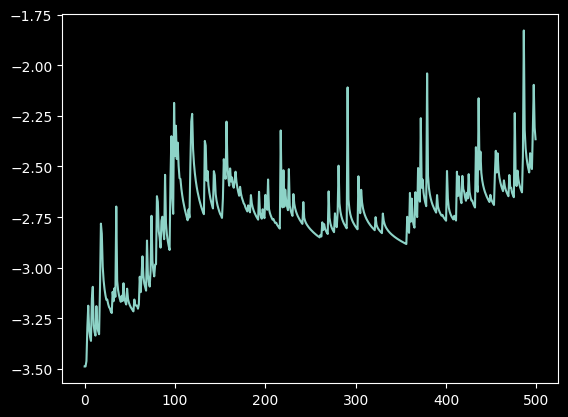

In [17]:
plt.plot(df_curves.iloc[0, 2])

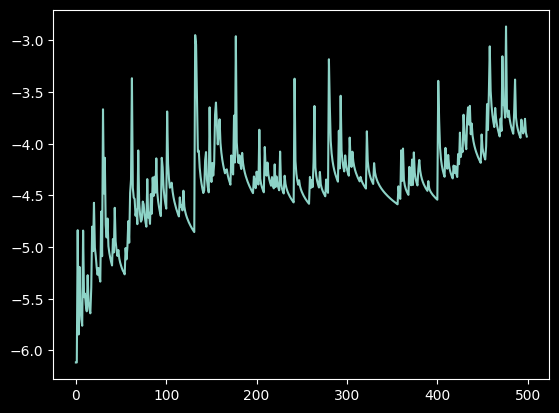

In [18]:
plt.plot(df_curves.iloc[1, 2])

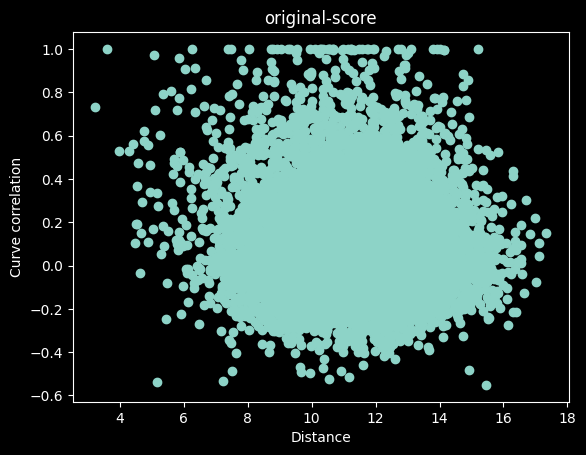

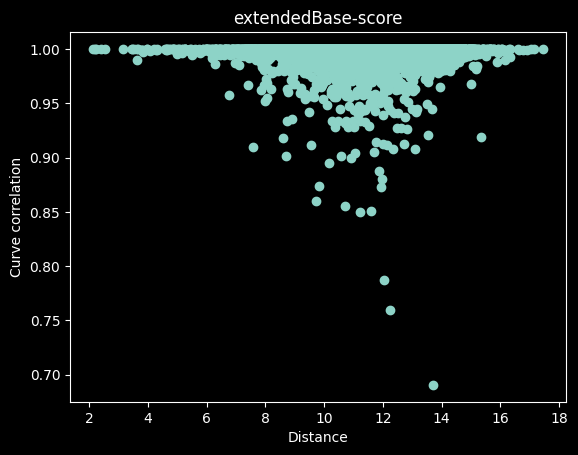

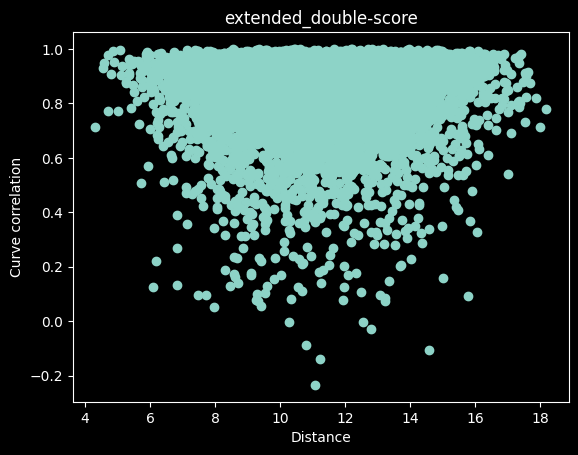

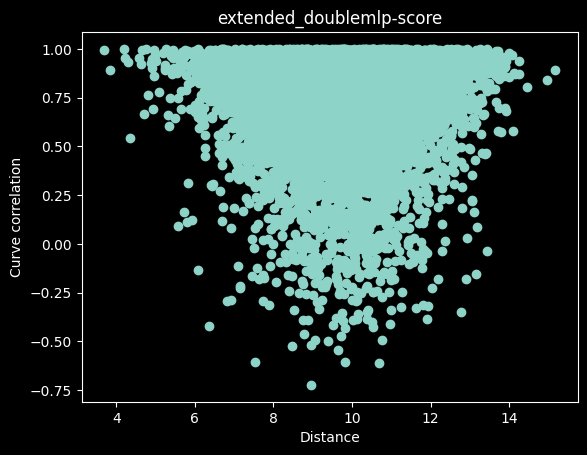

In [19]:
def interpolate_array(arr):
    arr_float = arr.astype(float)
    valid = ~np.isnan(arr_float)
    indices = np.arange(len(arr_float))
    arr_float[np.isnan(arr_float)] = np.interp(indices[np.isnan(arr_float)], indices[valid], arr_float[valid])
    return arr_float

for m in models:
    df_list = []
    weights_list = []

    weights = torch.load(f'{weight_path}/{m}/weights.pt', map_location='cpu', weights_only=False)

    emb_items = weights['model_state_dict']['embedding_item.weight'].numpy()

    df_path = f'{data_path}/{m}_predictions_for_curves.csv'
    df = pd.read_csv(df_path)

    df['score'] = df['score'].apply(lambda x: np.array(ast.literal_eval(re.sub(r'np\.float64\(([^)]+)\)', r'\1', x).replace('nan', 'None')))).apply(interpolate_array)
    df['prob'] = df['prob'].apply(lambda x: np.array(ast.literal_eval(re.sub(r'np\.float64\(([^)]+)\)', r'\1', x).replace('nan', 'None')))).apply(interpolate_array)
    df['item'] = df['item'].astype(int)
    df['user'] = df['user'].astype(int)




    df_grouped = df.groupby(['user']).agg(
            score=('score', similarity),
            prob=('prob', similarity),
            item_dist=('item', lambda x: np.linalg.norm(emb_items[x.iloc[0], :] - emb_items[x.iloc[1], :]))
        )


    df_shorten = df_grouped.dropna()

    plt.figure()
    plt.scatter(df_shorten['item_dist'], df_shorten['score'])
    plt.title(f'{m}-score')
    plt.xlabel('Distance')
    plt.ylabel('Curve correlation')


    # plt.figure()
    # plt.scatter(df_shorten['item_dist'], df_shorten['prob'])
    # plt.title(f'{m}-prob')
    # plt.xlabel('Distance')
    # plt.ylabel('Curve correlation')

    df_shorten.to_csv(f'../optimized/analysis/curve_sim_{m}.csv')

In [20]:
df

,user,item,score,prob
0,1,208,"[-3.487718105316162, -3.487718105316162, -3.46...","[0.0010720934951677918, 0.0010720934951677918,..."
1,1,380,"[-6.115856170654297, -6.115856170654297, -4.83...","[7.741886656731367e-05, 7.741886656731367e-05,..."
2,2,594,"[-8.33913803100586, -8.33913803100586, -8.3391...","[0.0001678132830420509, 0.0001678132830420509,..."
3,2,673,"[-4.424111366271973, -4.424111366271973, -4.42...","[0.008415904827415943, 0.008415904827415943, 0..."
4,3,71,"[-4.488868236541748, -4.488868236541748, -4.48...","[0.0010777079733088613, 0.0010777079733088613,..."
...,...,...,...,...
26413,13207,1055,"[-9.996683120727539, -9.996683120727539, -9.99...","[1.6910671547520906e-05, 1.6910671547520906e-0..."
26414,13208,1311,"[-6.347343921661377, -6.347343921661377, -5.56...","[0.0008481089025735855, 0.0008481089025735855,..."
26415,13208,1640,"[-5.819157123565674, -5.819157123565674, -5.58...","[0.0014382692752406001, 0.0014382692752406001,..."
26416,13209,453,"[-6.58095645904541, -6.58095645904541, -6.5809...","[0.00031384016619995236, 0.0003138401661999523..."


In [21]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def get_dist_weight(dist, smooth, force):
    return sigmoid(smooth / (1 + dist) - force * smooth) / sigmoid(smooth - force * smooth)

def get_weighted_dist(dist, smooth, force):
    return 1 / (1 + dist) * get_dist_weight(dist, smooth, force)

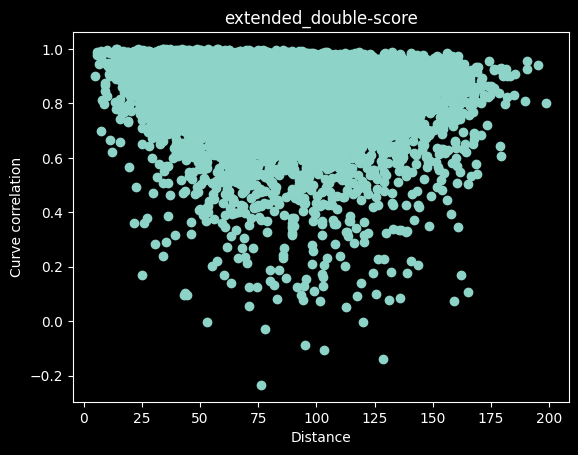

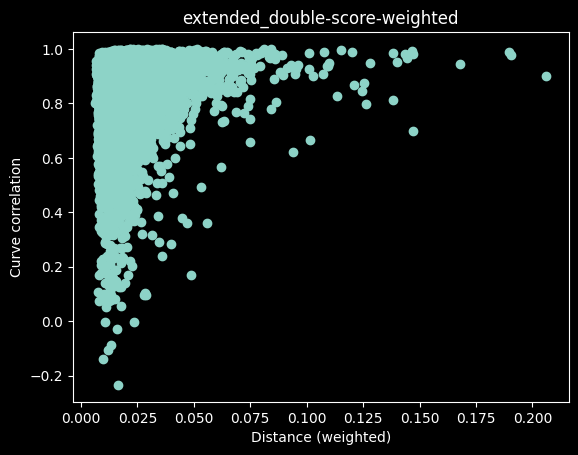

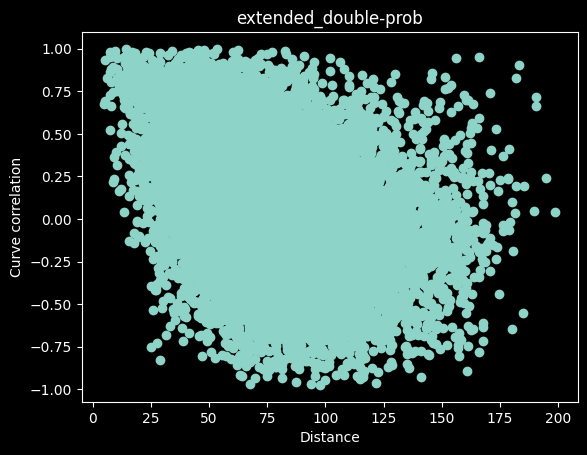

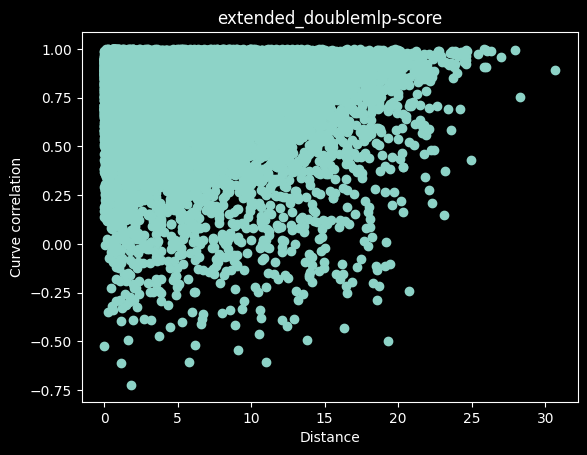

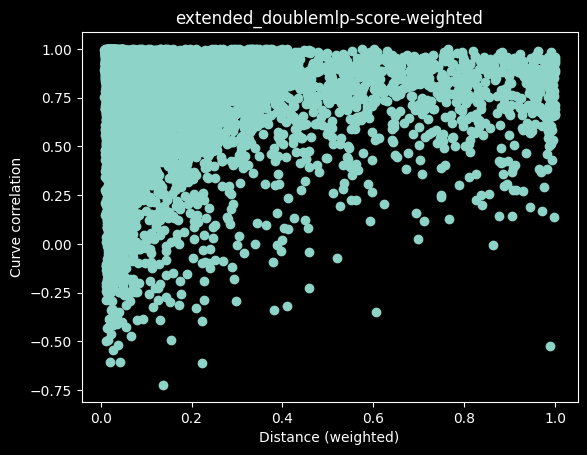

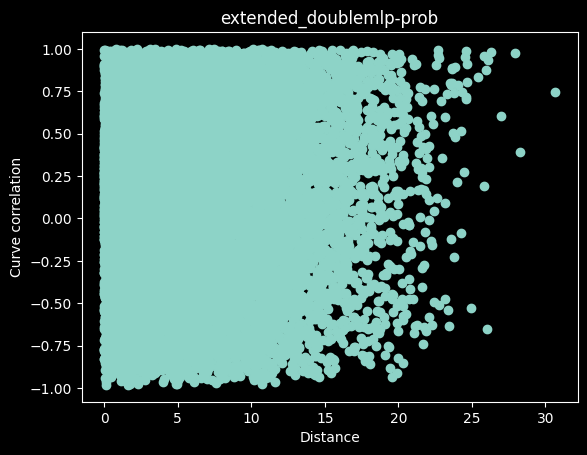

In [22]:
for m in ['extended_double', 'extended_doublemlp']:
    df_list = []
    weights_list = []

    weights = torch.load(f'{weight_path}/{m}/weights.pt', map_location='cpu', weights_only=False)

    smooth = weights['model_state_dict']['smooth'].cpu().numpy()
    force = weights['model_state_dict']['force'].cpu().numpy()

    emb_items = weights['model_state_dict']['embedding_item_extension.weight'].numpy()

    df_path = f'{data_path}/{m}_predictions_for_curves.csv'
    df = pd.read_csv(df_path)

    df['score'] = df['score'].apply(lambda x: np.array(ast.literal_eval(re.sub(r'np\.float64\(([^)]+)\)', r'\1', x).replace('nan', 'None')))).apply(interpolate_array)
    df['prob'] = df['prob'].apply(lambda x: np.array(ast.literal_eval(re.sub(r'np\.float64\(([^)]+)\)', r'\1', x).replace('nan', 'None')))).apply(interpolate_array)
    df['item'] = df['item'].astype(int)
    df['user'] = df['user'].astype(int)

    if m == 'extended_doublemlp':
        max_history = 3500
        user_count = df_full['user_id'].max()
        item_count = df_full['track_id'].max()

        device = 'cpu'
        config = {'n_users': user_count, 'n_items': item_count, 'latent_d': 64,
                  'pretrained_embeddings_path': r'Z:/Skola/ING/Recommenders/repo/Ex2VecExtended/split_data/track_embeddings.parquet',
                  'item_mapping': r'Z:\Skola\ING\Recommenders\repo\Ex2VecExtended\split_data\item_mapping.json',
                  'mlp_dist_conf': {
                    'emb_dim': 128,
                    'hidden_dims':[256, 128],
                    'block_size':512,
                    'activation':torch.nn.ReLU,
                    'dropout':0.1,
                    'positive_output':True
                  }}


        model = Ex2VecExtendedMLP(config)
        model.load_state_dict(weights["model_state_dict"], strict=False)
        model.to(device)

        model.eval()
        item_dist_matrix = model.metric(model.embedding_item_extension.weight).detach().cpu().numpy()

        df_grouped = df.groupby(['user']).agg(
                score=('score', similarity),
                prob=('prob', similarity),
                item_dist=('item', lambda x: item_dist_matrix[x.iloc[0], x.iloc[1]]),
                item_dist_weighted=('item', lambda x: get_weighted_dist(item_dist_matrix[x.iloc[0], x.iloc[1]], smooth, force))
            )
    else:

        df_grouped = df.groupby(['user']).agg(
                score=('score', similarity),
                prob=('prob', similarity),
                item_dist=('item', lambda x: np.linalg.norm(emb_items[x.iloc[0], :] - emb_items[x.iloc[1], :])),
                item_dist_weighted=('item', lambda x: get_weighted_dist(np.linalg.norm(emb_items[x.iloc[0], :] - emb_items[x.iloc[1], :]), smooth, force))
            )


    df_shorten = df_grouped.dropna()

    plt.figure()
    plt.scatter(df_shorten['item_dist'], df_shorten['score'])
    plt.title(f'{m}-score')
    plt.xlabel('Distance')
    plt.ylabel('Curve correlation')

    plt.figure()
    plt.scatter(df_shorten['item_dist_weighted'], df_shorten['score'])
    plt.title(f'{m}-score-weighted')
    plt.xlabel('Distance (weighted)')
    plt.ylabel('Curve correlation')

    plt.figure()
    plt.scatter(df_shorten['item_dist'], df_shorten['prob'])
    plt.title(f'{m}-prob')
    plt.xlabel('Distance')
    plt.ylabel('Curve correlation')

    df_shorten.to_csv(f'../optimized/analysis/curve_sim_{m}_extended.csv')

In [23]:
weights

{'model_state_dict': OrderedDict([('global_lamb', tensor(3.4894)),
              ('alpha', tensor(-0.2008)),
              ('beta', tensor(-0.0761)),
              ('gamma', tensor(1.8626)),
              ('cutoff', tensor(0.2805)),
              ('smooth', tensor(1.7840)),
              ('force', tensor(1.4765)),
              ('history_items',
               tensor([[   0,    0,    0,  ...,    0,    0,    0],
                       [   1,    2,    3,  ...,    0,    0,    0],
                       [ 576,  211,  577,  ...,    0,    0,    0],
                       ...,
                       [ 678,  276,  319,  ...,    0,    0,    0],
                       [1471, 2822, 2701,  ...,    0,    0,    0],
                       [ 699,  455,  396,  ...,    0,    0,    0]])),
              ('history_times',
               tensor([[         0,          0,          0,  ...,          0,          0,
                                 0],
                       [1654072390, 1654072708, 1654072940, 

(-0.1, 5.1)

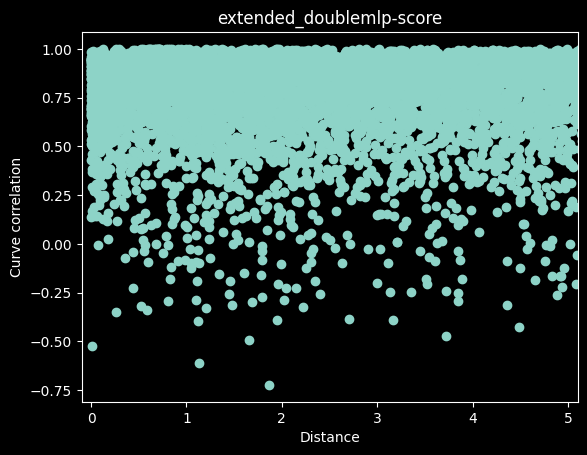

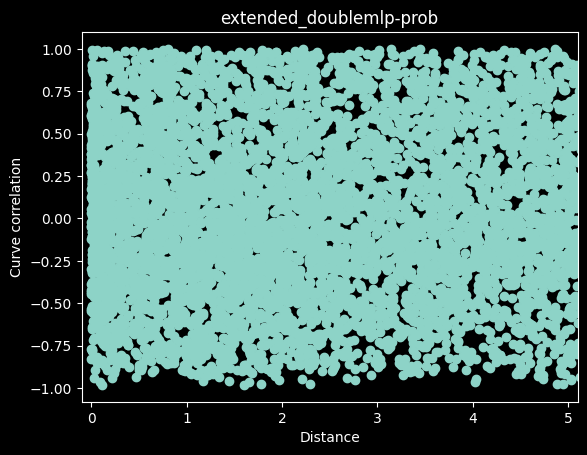

In [24]:
plt.figure()
plt.scatter(df_shorten['item_dist'], df_shorten['score'])
plt.title(f'{m}-score')
plt.xlabel('Distance')
plt.ylabel('Curve correlation')
plt.xlim((-0.1, 5.1))

plt.figure()
plt.scatter(df_shorten['item_dist'], df_shorten['prob'])
plt.title(f'{m}-prob')
plt.xlabel('Distance')
plt.ylabel('Curve correlation')
plt.xlim((-0.1, 5.1))

Text(0.5, 1.0, 'extended_doublemlp-score')

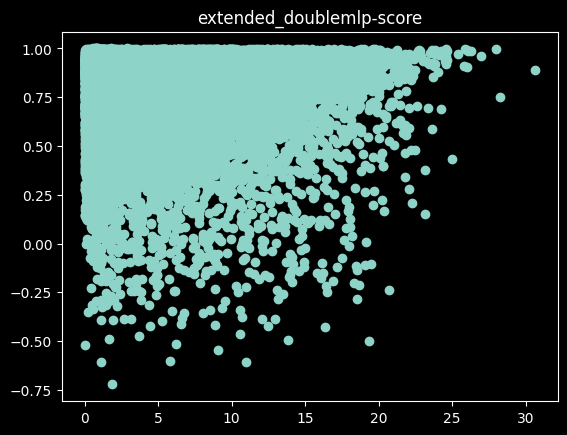

In [25]:
plt.figure()
plt.scatter(df_shorten['item_dist'], df_shorten['score'])
plt.title(f'{m}-score')



In [26]:
df_grouped = df.groupby(['user']).agg(
            score=('score', similarity),
            prob=('prob', similarity),
            item_dist=('item', lambda x: np.linalg.norm(emb_items[x.iloc[0], :] - emb_items[x.iloc[1], :]))
        )

(array([ 260., 1307., 2715., 3394., 2673., 1644.,  778.,  335.,   89.,
          14.]),
 array([  5.3207407 ,  24.705616  ,  44.09049225,  63.4753685 ,
         82.86024475, 102.24511719, 121.62999725, 141.01487732,
        160.39974976, 179.78462219, 199.16950989]),
 <BarContainer object of 10 artists>)

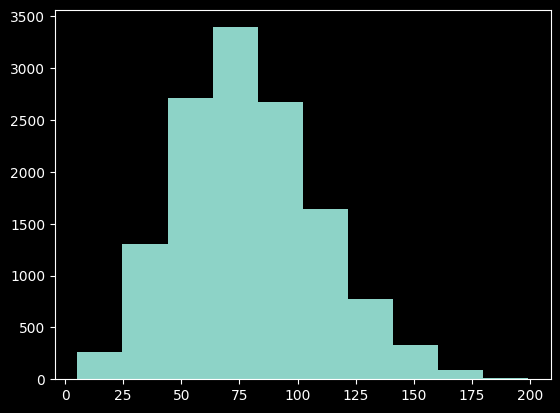

In [27]:
plt.hist(df_grouped['item_dist'])

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

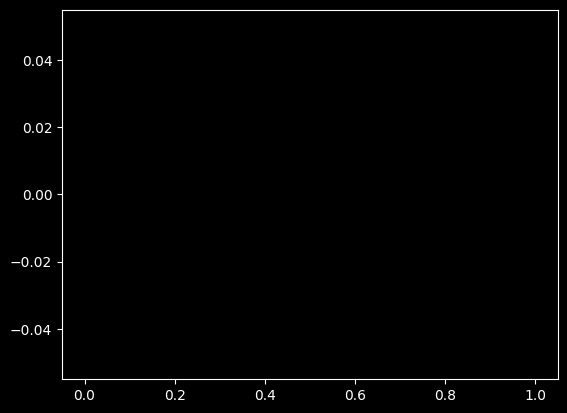

In [28]:
plt.hist(df_grouped[df_grouped.isna().to_numpy().sum(axis=1) > 0]['item_dist'])

In [29]:
df_shorten = df_grouped.dropna()

In [30]:
df_shorten

,score,prob,item_dist
user,,,
1,0.728347,-0.223955,160.041687
2,0.883390,0.424712,49.892258
3,0.810490,0.229147,155.606583
4,0.891922,-0.443417,102.987144
5,0.998264,0.864018,53.248329
...,...,...,...
13205,0.780092,-0.049094,90.187973
13206,0.979531,0.193015,49.092033
13207,0.948479,0.482755,97.889320


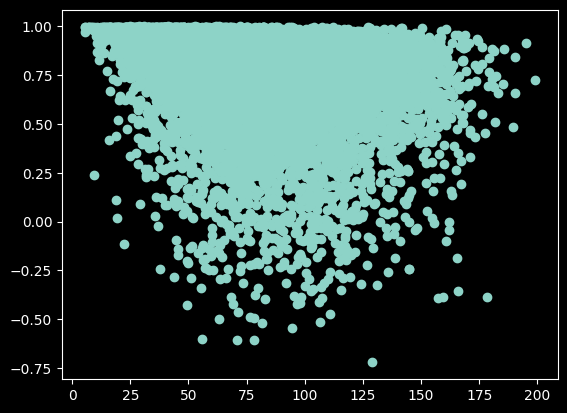

In [31]:
plt.scatter(df_shorten['item_dist'], df_shorten['score'])

In [26]:
models_double = ['extendedDoubleBase', 'extendedDoubleEmb', 'extendedDoubleEmbFreeze']


for m in models_double:
    df_list = []
    weights_list = []
    dir_path = f'{data_path}/{m}'
    for split in tqdm(splits):
        weights = torch.load(f'{weight_path}/{m}/split_{split}/checkpoint_best.pt', map_location='cpu')
        emb_items_base = weights['model_state_dict']['embedding_item_base.weight'].numpy()
        emb_items_ext = weights['model_state_dict']['embedding_item_extension.weight'].numpy()
        path = os.path.join(dir_path, f'split_{split}.csv')
        df = pd.read_csv(path)
        df['split'] = split
        df['score'] = df['score'].apply(lambda x: np.array(ast.literal_eval(re.sub(r'np\.float64\(([^)]+)\)', r'\1', x))))
        df['prob'] = df['prob'].apply(lambda x: np.array(ast.literal_eval(re.sub(r'np\.float64\(([^)]+)\)', r'\1', x))))
        df['item'] = df['item'].astype(int)
        df['user'] = df['user'].astype(int)
        df_list.append(df.groupby(['user', 'split']).agg(
            score=('score', similarity),
            prob=('prob', similarity),
            item_dist_base=('item', lambda x: np.linalg.norm(emb_items_base[x.iloc[0], :] - emb_items_base[x.iloc[1], :])),
            item_dist_ext=('item', lambda x: np.linalg.norm(emb_items_ext[x.iloc[0], :] - emb_items_ext[x.iloc[1], :]))
        ).reset_index(level="split"))

    pd.concat(df_list, ignore_index=True).to_csv(f'../analysis/sim_analysis/{m}.csv')

NameError: name 'splits' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

# Example 2D scatter data
X = out_df['item_dist'].to_numpy()
Y = out_df['prob'].to_numpy()

# --- Step 1: Fit linear regression using statsmodels ---
X_sm = sm.add_constant(X)  # adds intercept term
model = sm.OLS(Y, X_sm)    # Ordinary Least Squares
results = model.fit()       # Fit the model

# --- Step 2: Regression results ---
print(results.summary())

# --- Step 3: Plot data and regression line ---
plt.scatter(X, Y, label='Data')
plt.plot(X, results.predict(X_sm), color='red', label='Fit')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression')
plt.legend()
plt.show()

# --- Optional Step 4: Residual analysis ---
residuals = Y - results.predict(X_sm)
plt.scatter(X, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('X')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [ ]:
X_poly = np.column_stack((X, X**2))
X_poly = sm.add_constant(X_poly)  # add intercept

model_poly = sm.OLS(Y, X_poly)
results_poly = model_poly.fit()
print(results_poly.summary())

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

# Example 2D scatter data
X = out_df['item_dist'].to_numpy()
Y = out_df['prob'].to_numpy()

# --- Step 1: Fit linear regression using statsmodels ---
X_sm = sm.add_constant(X)  # adds intercept term
model = sm.OLS(Y, X_sm)    # Ordinary Least Squares
results = model.fit()       # Fit the model

# --- Step 2: Regression results ---
print(results.summary())

# --- Step 3: Plot data and regression line ---
plt.scatter(X, Y, label='Data')
plt.plot(X, results.predict(X_sm), color='red', label='Fit')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression')
plt.legend()
plt.show()

# --- Optional Step 4: Residual analysis ---
residuals = Y - results.predict(X_sm)
plt.scatter(X, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('X')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [ ]:
out_df.sort_values('score')

In [ ]:
out_df['score'].min()

In [ ]:
np.diff(df[(df['user'] == 117)].iloc[0, 2])

In [ ]:
plt.plot(np.diff(df[(df['user'] == 117)].iloc[0, 2]))
plt.plot(np.diff(df[(df['user'] == 117)].iloc[1, 2]))

In [ ]:
plt.plot(df[(df['user'] == 7870)].iloc[0, 3])
plt.plot(df[(df['user'] == 7870)].iloc[1, 3])

In [ ]:
out_df.sort_values('score')

In [ ]:
plt.plot(df[(df['user'] == 213)].iloc[0, 2] - df[(df['user'] == 213)].iloc[1, 2])

In [ ]:
df[(df['user'] == 213)].iloc[0, 2]

In [ ]:
df[(df['user'] == 213)].iloc[1, 2]

In [ ]:
plt.plot(df[(df['user'] == 213)].iloc[0, 2])
plt.plot(df[(df['user'] == 213)].iloc[1, 2])

In [ ]:
plt.plot(df[(df['user'] == 213)].iloc[0, 3])
plt.plot(df[(df['user'] == 213)].iloc[1, 3])